In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_designs = pd.read_csv("designs/gRNAde.csv")
# remove duplicates
df_designs = df_designs.drop_duplicates(subset="sequence")
# remove designs that do not start with 'GG'
df_designs = df_designs[df_designs['sequence'].str.startswith("GG")]
df_designs

,fasta_desc,sequence,model,seed,temperature,edit_dist,perplexity,sc_score_ribonanzanet,sc_score_ribonanzanet_ss
0,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=1824 te...,GGCUCUUCUCGAGCGAACCAGAAAGACAAAUCGGCCGAAAAGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,1824,0.624356,25,1.333659,0.131749,0.769081
1,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=1824 te...,GGGUCUUCUCGACCGAACCGACAAGACAAAUCCGCCAGAAAGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,1824,0.624356,21,1.325341,0.136344,0.710107
2,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=1824 te...,GGGUCUUCUCGACCAAUCGAAAAAGACAAAUCUGCCUAAAAGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,1824,0.624356,30,1.352397,0.144222,0.609950
3,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=9540 te...,GGAGAUUCUCGCUCCUAAAAACAAGACAAAUCUUCUAAAAAGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,9540,0.325954,34,1.365326,0.146915,0.745171
4,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=9540 te...,GGAGUUUCUCGCUCGUAUUAACAAGACAAAUCUGUUAGAAAGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,9540,0.325954,38,1.358482,0.146716,0.609776
...,...,...,...,...,...,...,...,...,...
41898,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=590 tem...,GGAUCUUCUCGAUCUAACAACCAAGACAAAUCUGCCAGAAUGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,590,0.509586,18,1.217016,0.123987,0.868166
41899,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=590 tem...,GGAUCUUCUCGAUCUAUCAAUCAAGACAAAUCUGCCAGAAUGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,590,0.509586,21,1.206577,0.125840,0.888456
41900,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=590 tem...,GGAUCUUCUCGAUCCAGCAAACAAGACAAAUCUGCCAUAAUGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,590,0.509586,20,1.209280,0.125080,0.886540
41901,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=590 tem...,GGAUCUUCUCGAUCUAUCAAACAAGACAAAUCUGCCAGAACGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,590,0.509586,25,1.226838,0.134079,0.856712


Number of unique designs passing filter: 40466


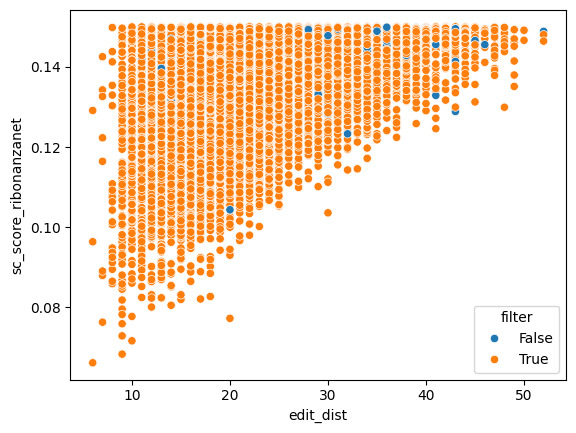

In [6]:
# Create new column 'filter' set to True if design sc_score_ribonazanet_ss >= 0.8
df_designs['filter'] = df_designs['sc_score_ribonanzanet_ss'] >= 0.5
print("Number of unique designs passing filter:", df_designs['filter'].sum())

sns.scatterplot(data=df_designs, x='edit_dist', y='sc_score_ribonanzanet', hue='filter')
plt.show()

In [ ]:
top_n = 40
min_edit_dist = 15
max_edit_dist = 40

df_final_designs = pd.DataFrame()

for edit_dist in range(min_edit_dist, max_edit_dist):
    # filter designs by edit_dist
    _df = df_designs[(df_designs.edit_dist == edit_dist) & (df_designs['filter'])]
    # add top n designs by lowest sc_score_ribonanzanet to df_final_designs
    df_final_designs = pd.concat(
        [
            df_final_designs, 
            _df.sort_values(by="sc_score_ribonanzanet").head(top_n)
        ]
    )
    
# remove 'filter' column
df_final_designs = df_final_designs.drop(columns=['filter'])
# save final designs to csv
df_final_designs.to_csv(f"final_designs/gRNAde_{pd.Timestamp.now().strftime('%d%m%Y')}.csv", index=False)
df_final_designs

,fasta_desc,sequence,model,seed,temperature,edit_dist,perplexity,sc_score_ribonanzanet,sc_score_ribonanzanet_ss
17395,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=3090 te...,GGAUCUUCUCGAUCUAUUAAAAAAGACAAAUCUGCCACAAAGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,3090,0.441924,15,1.235233,0.081990,0.809393
28516,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=6802 te...,GGAUCUUCUCGAUCUAAUCAAAAAGACAAAUCUGCCACAAAGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,6802,0.632620,15,1.212259,0.083147,0.830978
3543,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=6802 te...,GGAUCUUCUCGAUCUAACCAACAAGACAAAUCUGCCACAAAGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,6802,0.632620,15,1.197458,0.089538,0.830978
10577,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=3809 te...,GGAUCUUCUCGAUCCACGAAACAAGACAAAUCUGCCACAAUGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,3809,0.743550,15,1.171488,0.091939,0.917109
33412,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=8374 te...,GGAUCUUCUCGAUCUAUUCUACAAGACAAAUCUGCCAGAAUGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,8374,0.327370,15,1.167326,0.092202,0.872379
...,...,...,...,...,...,...,...,...,...
10679,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=1829 te...,GGAUCUUCUCGAUCCAUUUAAAAAGACAAAUGGGCCGUAAUGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,1829,0.224972,39,1.425988,0.141709,0.842633
37822,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=3796 te...,GGAUUUUCUCGGUCUAACCCACAAGACAAAUCUGCCACAAUGCUUU...,gRNAde2_drop3d@0.75_maxlen@500.h5,3796,0.457946,39,1.296651,0.141751,0.717494
10908,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=5132 te...,GGAUUUUCUCGAUCUUUUUAGUAAGACAAAUGGGCCGCAAUGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,5132,0.139582,39,1.361308,0.141821,0.754215
18835,gRNAde2_drop3d@0.75_maxlen@500.h5 seed=1829 te...,GGAUCUUCUCGAUCCAUUUUUCAAGACAAAUCUUCCGAAAAGCUUG...,gRNAde2_drop3d@0.75_maxlen@500.h5,1829,0.224972,39,1.359044,0.142045,0.766579


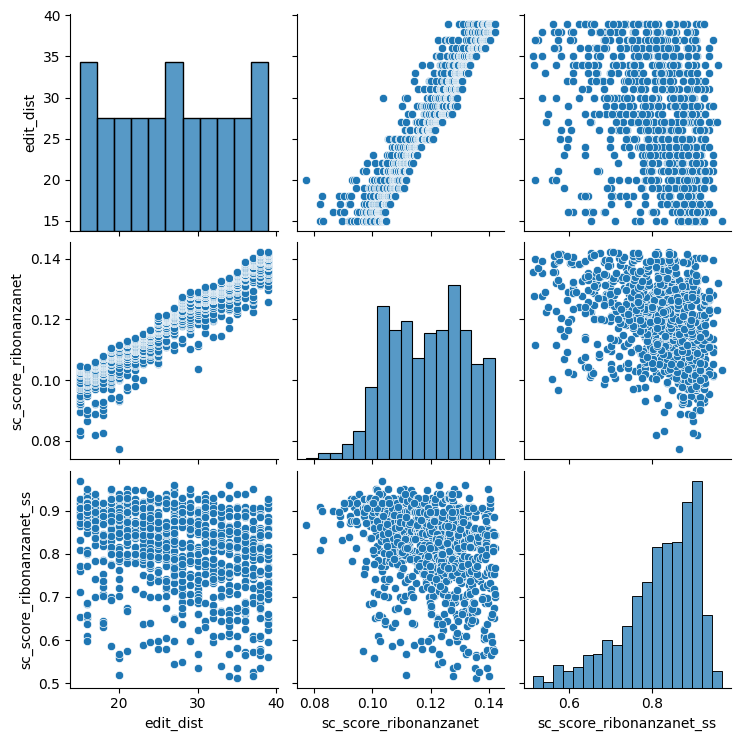

In [ ]:
sns.pairplot(
    df_final_designs,
    x_vars=['edit_dist', 'sc_score_ribonanzanet', 'sc_score_ribonanzanet_ss'],
    y_vars=['edit_dist', 'sc_score_ribonanzanet', 'sc_score_ribonanzanet_ss'],
)
plt.show()